In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score 

In [2]:
shop_df = pd.read_csv("shop_smart_ecommerce.csv")
# shop_df.info() # so there is no null or missing values
shop_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


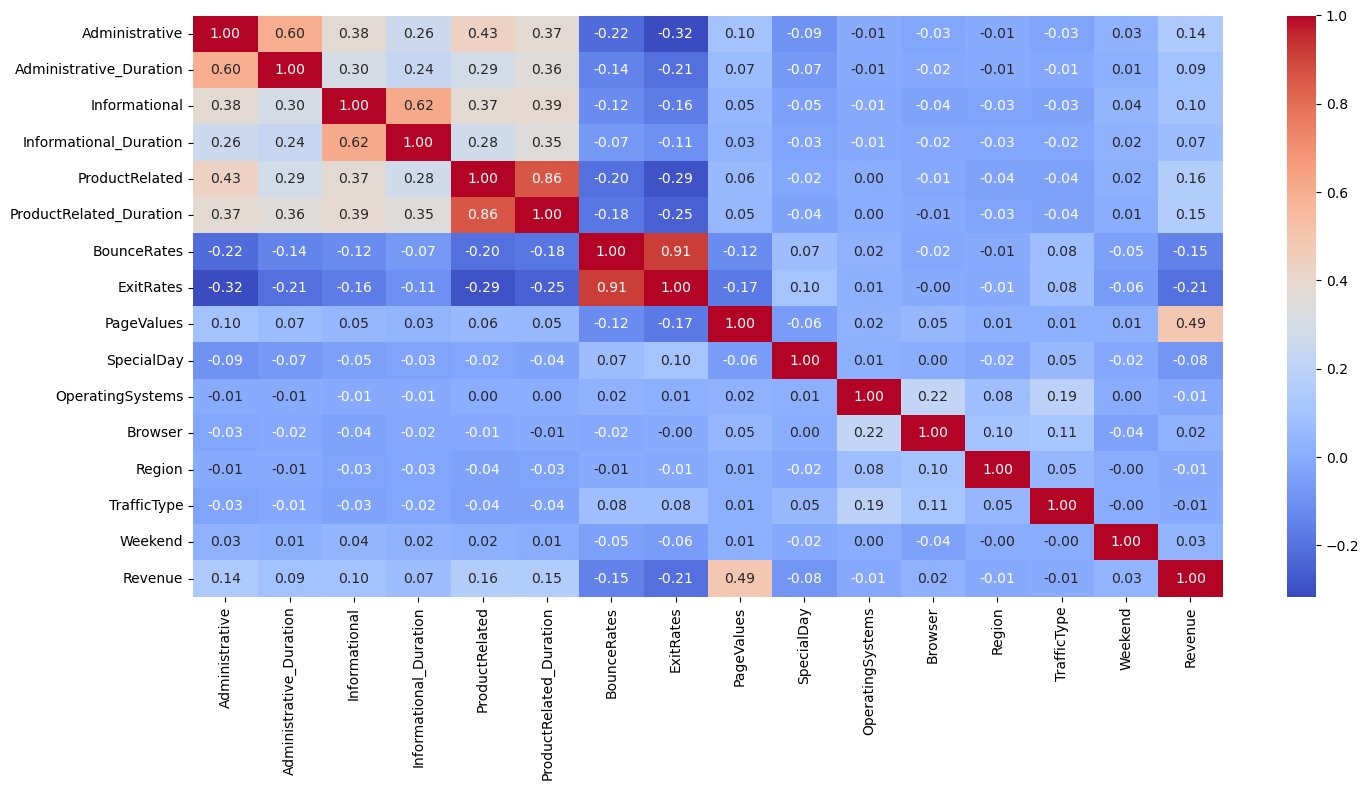

In [3]:
num_cols = shop_df.select_dtypes(include=["number","bool"])
corr_matrix = num_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.tight_layout()

In [4]:
#  cleaning and handling data 
cat_col = ["Month","VisitorType","OperatingSystems","Browser","Region","TrafficType"]
oe = OneHotEncoder(drop="first",sparse_output=False)
oe_data = oe.fit_transform(shop_df[cat_col])
oe_df = pd.DataFrame(
    oe_data,
    columns=oe.get_feature_names_out(cat_col)
)
oe_df = oe_df.reset_index(drop=True) # reset index bcs it prevent unnecesary NAN columns
shop_df = shop_df.reset_index(drop=True)
shop_df = pd.concat([shop_df.drop(cat_col,axis=1),oe_df],axis=1)
shop_df[["Weekend","Revenue"]] = shop_df[["Weekend","Revenue"]].astype(int)
# shop_df["Revenue"]

In [16]:
x = shop_df.drop("Revenue",axis=1)
y = shop_df["Revenue"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)
model = DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(f1_score(y_test,y_pred))

0.5428571428571428


In [17]:
# pre pruning ,min_samples_split 
max_depths = [3,4,5,9,8]
min_samples_splits = [15,20,25,30,35]
for depth in max_depths :
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    print("f1_score : ",f1_score(y_test,y_pred),"   depth: ",depth)
    
 #  so i got better f1 score at max_depths = 5


f1_score :  0.6392045454545454    depth:  3
f1_score :  0.5816993464052288    depth:  4
f1_score :  0.642754662840746    depth:  5
f1_score :  0.599713055954089    depth:  9
f1_score :  0.5956204379562043    depth:  8


In [11]:
ccp_alphas =[0.001,0.02,0.0005,0.0001]
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(max_depth = 5,ccp_alpha =alpha)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    print("f1_score : ",f1_score(y_test,y_pred),"   ccp_alpha: ",alpha)
    

f1_score :  0.5816993464052288    ccp_alpha:  0.001
f1_score :  0.6431718061674009    ccp_alpha:  0.02
f1_score :  0.6457142857142857    ccp_alpha:  0.0005
f1_score :  0.6437768240343348    ccp_alpha:  0.0001
